In [2]:
%load_ext autoreload
%autoreload 2

### Eval Losses

plot training and validation losses from training

In [1]:
import matplotlib.pyplot as plt
import json, os

In [3]:
def load_loss(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

holders = [None, None]
for ver in [6, 7]:
    file_path = f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{ver}/train_val_loss.json"
    holders[ver - 6] = load_loss(file_path)

In [8]:
# new gen of training doesn't store loss in the same way (older version is below)
i = 1
train_holder = holders[i][list(holders[i].keys())[0]]['train']
val_holder = holders[i][list(holders[i].keys())[0]]['train']
# print(holders[i])
# print(holders[i][list(holders[i].keys())[0]]['train'])
train_loss = []
clip_loss = []
loc_loss = []
id_loss = []
for train, val in zip(train_holder, val_holder):
    train_loss.append(train['total'])
    clip_loss.append(train['clip'])
    loc_loss.append(train['loc'])
    id_loss.append(train['id'])

print(train_loss)

[5.161538889272839, 2.8644410644693576, 2.441524907392813, 2.2244213074741634, 2.0904081522657516, 1.9944635714453163, 1.9231732949128388, 1.8686087494961758, 1.8238370313881136, 1.7850075827253626, 1.7536230822911498, 1.7240631742511234, 1.6983699690281078, 1.6747063590702436, 1.6505372281446524, 1.6298027608496077, 1.6107173019140324, 1.5919875739990397, 1.576411737321962, 1.561802129711665, 1.5482125598910852, 1.5315501179424584, 1.5171590800868704, 1.505566145743884, 1.489293741613415, 1.4794483797854565, 1.4681826130887294, 1.457011421978051, 1.4471888234387054, 1.4362813621294415, 1.4273665118428833, 1.4190003801491244, 1.4098482030165111, 1.4017388645511992, 1.3951039360854642, 1.3860982258184582, 1.3784589894866266, 1.3691599463697866, 1.3632751537003416, 1.356679447403191, 1.350765973329544, 1.3422075365621147, 1.3357222382777125, 1.3294415465821612, 1.3224716936823324, 1.3168129921593565, 1.3106873948903794, 1.3040940346193652, 1.2972630008273092, 1.2928462396868576]


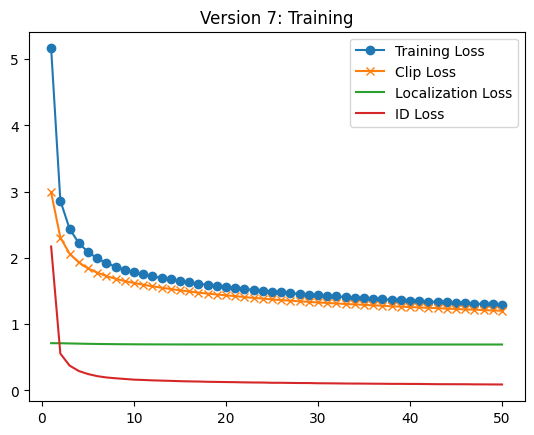

In [9]:
ver = [6, 7][i]
epochs = range(1, len(train_loss) + 1)
plt.title(f'Version {ver}: Training')
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, clip_loss, label='Clip Loss', marker='x')
plt.plot(epochs, loc_loss, label='Localization Loss')
plt.plot(epochs, id_loss, label='ID Loss')
plt.legend()
plt.show()

TypeError: unhashable type: 'dict'

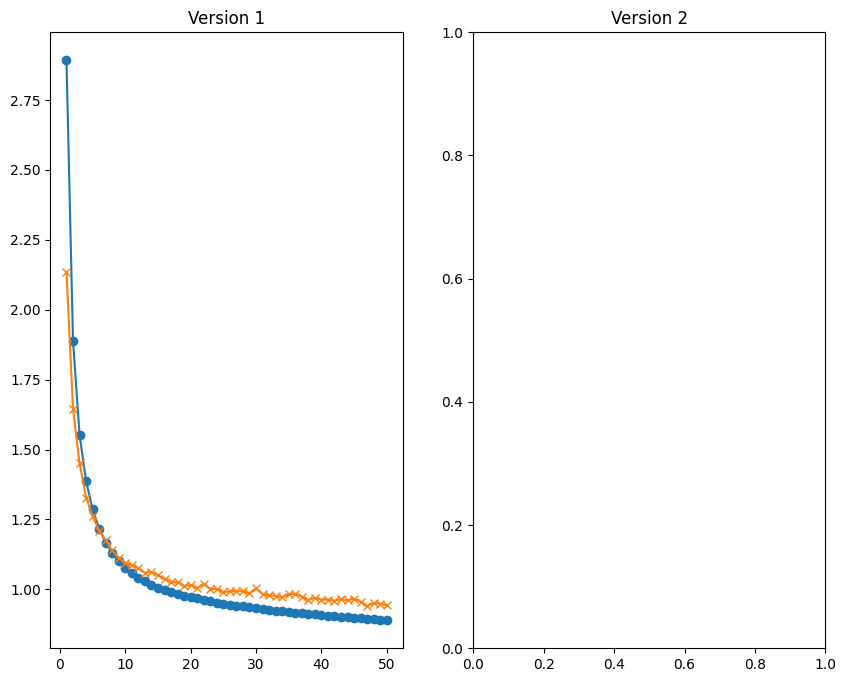

In [6]:
epochs = range(1, len(holders[0][list(holders[0].keys())[0]]['train']) + 1)
fig, axs = plt.subplots(ncols=2, figsize=(10, 8))

def set_ax(ax, version, loss):
    epochs = range(1, len(loss[list(loss.keys())[0]]['train']) + 1)
    ax.set_title(f'Version {version}')
    ax.plot(epochs, loss[list(loss.keys())[0]]['train'], label='Training loss', marker='o')
    # Plot validation loss
    ax.plot(epochs, loss[list(loss.keys())[0]]['val'], label='Validation loss', marker='x')

set_ax(axs[0], 1, holders[0])
set_ax(axs[1], 2, holders[1])

plt.show()

In [17]:
loss_range = []
for holder in holders:
    tloss = holder[list(holder.keys())[0]]['train']
    diff = max(tloss) - min(tloss)
    print(f"{max(tloss)} - {min(tloss)} --> {diff}")
    loss_range.append(diff)

2.8770269538132345 - 0.9833286508091054 --> 1.893698303004129
2.898617761533011 - 0.9193038401129471 --> 1.9793139214200641
2.8946523597933655 - 0.9397208977410748 --> 1.9549314620522908
2.8918259175704724 - 0.889604765156093 --> 2.0022211524143794


#### Misc.

In [1]:
## quickly check the storage mode of subcell embeddings
import torch 

data = torch.load('/scratch/users/samutiti/U54/embeddings/all_harmonized_features_microscope_vit.pth', weights_only=False)

In [3]:
print(type(data))
print(type(data[0]))
print(type(data[1]))

<class 'tuple'>
<class 'pandas.DataFrame'>
<class 'torch.Tensor'>


In [5]:
print(data[1].shape)

torch.Size([1138378, 1536])


### Eval inference outputs

evaluate embeddings / set up for PCA and Umapping

In [3]:
import anndata as ad 

training_v = 5
embeddings = ad.read_h5ad(f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{training_v}/inference_U2OS_analyzed.h5ad")

In [4]:
print(embeddings)
adata = embeddings

# print(adata.obs['locations'])

AnnData object with n_obs × n_vars = 293106 × 1280
    obs: 'gene_name', 'gene_idx', 'locations', 'atlas_name', 'leiden_0.3', 'umap_x', 'umap_y'
    uns: 'leiden_0.3', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'h'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [ ]:
import scanpy as sc

NUM_PCS = 50
LEI_RES = 0.3

sc.pp.pca(
        adata,
        n_comps=NUM_PCS,
        svd_solver="arpack"
    )
print('pca complete')

sc.pp.neighbors(
        adata,
        n_neighbors=30,
        n_pcs=NUM_PCS,
    )
print('nieghbors complete')

sc.tl.leiden(
        adata,
        resolution=LEI_RES,
        key_added=f'leiden_{LEI_RES}'
    )
print('leiden complete')

sc.tl.umap(
        adata,
        min_dist=0.1,
    )

print('umap complete')

adata.obs["umap_x"] = adata.obsm["X_umap"][:, 0]
adata.obs["umap_y"] = adata.obsm["X_umap"][:, 1]

### Visualize Umap
sc.pl.umap(
        adata,
        color=[f"leiden_{LEI_RES}"],
        show=False,
        save=f"_training_V0{training_v}_mlp_embed.png"
    )


### Generate UMAPs

In [14]:
import anndata as ad
import seaborn as sns
import numpy as np

In [6]:
del embeddings
train_v = 5
adata_path = f"/scratch/users/samutiti/U54/SubCellNuc/training_V0{train_v}/inference_U2OS_analyzed.h5ad"
adata = ad.read_h5ad(adata_path)
print(adata)

AnnData object with n_obs × n_vars = 293106 × 1280
    obs: 'gene_name', 'gene_idx', 'locations', 'atlas_name', 'leiden_0.3', 'umap_x', 'umap_y'
    uns: 'leiden_0.3', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'h'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


<Axes: xlabel='umap_x', ylabel='umap_y'>

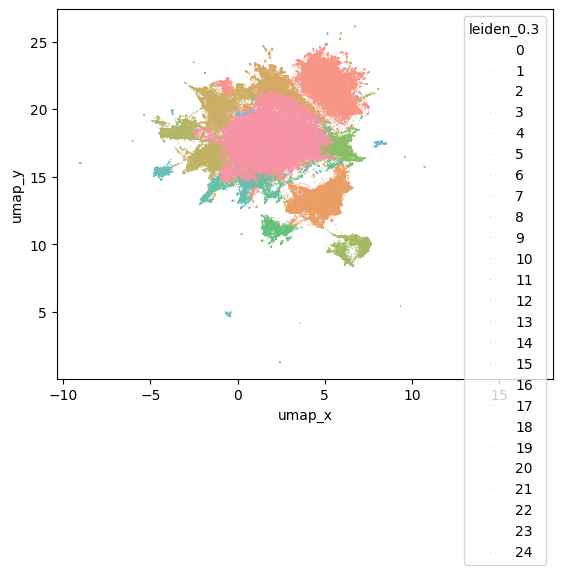

In [9]:
sns.scatterplot(
    data=adata.obs,
    x="umap_x",
    y="umap_y",
    hue="leiden_0.3",
    s=0.5,
    alpha=0.8
)

In [25]:
### Color By XAP
# Normalize function
def normalize_gene(g):
    return g.replace("-", "").replace("_", "").strip().upper()

# ADD TO THIS LIST
xap_set_normalized = {normalize_gene(g) for g in {
"HMGB1", "ILF2", "XRN2", "POLDIP3", "RNF20", "FUBP3", "HNRPLL", "ILF3",
"SSB", "SRRT", "EIF4A3", "RNMT", "PTBP2", "SAP18", "WTAP", "KHDRBS1",
"ERH", "CIZ1", "HNRNPH3", "SYNCRIP", "NONO", "FUS", "DHX9", "RALY",
"DDX17", "HNRPDL", "KHSRP", "RNF2", "HNRNPA3", "HNRNPUL2", "HNRNPD",
"DDX5", "DDX39B", "PTBP1", "HNRNPR", "ZFR", "ELAVL1", "SRSF2",
"HNRNPM", "RBMXL1", "TARDBP", "MYEF2", "HNRNPU", "HNRNPC",
"HNRNPL", "HNRNPAB", "HNRNPK", "HNRNPA2B1", "HNRNPA1",
"HNRNPA0", "RBM14", "TRA2B", "SFPQ", "IGF2BP1", "SARNP",
"SRSF3", "MATR3", "SRSF5", "SPEN", "RBM15", "RBM3",
"SRSF7", "RBFOX2", "SRSF9", "SAFB", "THOC4", "DDX39A",
"CELF1", "PCGF5", "RYBP", "TRIM71", "SRSF10", "RBM4",
"YTHDC1", "TRIM6", "LIN28A", "SLTM", "SAFB2", "L1TD1",
"MYBBP1A", "IGF2BP3", "SPEN", "RNF20", "RNF20", "MATR3", "HNRNPA0"
}}

def is_xap(gene_string):
    # genes = [normalize_gene(g) for g in gene_string.split(",")]
    gene = normalize_gene(gene_string)
    if gene in xap_set_normalized:
        return "XAPs"
    return "Other Proteins"

adata_filtered = adata[adata.obs['gene_name'] != '']
adata_filtered.obs['XAP'] = [is_xap(g) for g in adata_filtered.obs['gene_name']]
print(np.unique(adata_filtered.obs['gene_name']))
print(np.unique(adata_filtered.obs['XAP']))

/tmp/ipykernel_1461/3001893695.py:31: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_filtered.obs['XAP'] = [is_xap(g) for g in adata_filtered.obs['gene_name']]


['A1CF' 'A4GALT' 'AAAS' 'AADAT' 'AAGAB' 'AAK1' 'AAMDC' 'AAMP' 'AANAT'
 'AAR2' 'AARD' 'AARS1' 'AARS2' 'AARSD1,PTGES3L-AARSD1' 'AASS' 'AATF'
 'AATK' 'ABAT' 'ABCA1' 'ABCA12' 'ABCA13' 'ABCA2' 'ABCA4' 'ABCA5' 'ABCA6'
 'ABCA7' 'ABCA8' 'ABCA9' 'ABCB1' 'ABCB11' 'ABCB4' 'ABCB6' 'ABCB8' 'ABCB9'
 'ABCC1' 'ABCC4' 'ABCC5' 'ABCC6' 'ABCC8' 'ABCC9' 'ABCD3' 'ABCE1' 'ABCF1'
 'ABCF2' 'ABCF2,ABCF2-H2BK1' 'ABCF3' 'ABCG1' 'ABCG2' 'ABCG8' 'ABHD10'
 'ABHD11' 'ABHD12B' 'ABHD14A' 'ABHD14A,ABHD14A-ACY1' 'ABHD14A-ACY1,ACY1'
 'ABHD14B' 'ABHD16B' 'ABHD17A' 'ABHD2' 'ABHD3' 'ABHD4' 'ABHD5' 'ABHD6'
 'ABHD8' 'ABI1' 'ABI2' 'ABITRAM' 'ABL1' 'ABL2' 'ABLIM1' 'ABR' 'ABRACL'
 'ABRAXAS1' 'ABRAXAS2' 'ABT1' 'ABTB1' 'ABTB2' 'ABTB3' 'ACAA1' 'ACAA2'
 'ACACA' 'ACAD9' 'ACADM' 'ACADS' 'ACADSB' 'ACADVL' 'ACAP1' 'ACAP2' 'ACAP3'
 'ACAT1' 'ACAT2' 'ACBD3' 'ACBD4' 'ACBD5' 'ACBD6' 'ACBD7' 'ACCS' 'ACCSL'
 'ACE' 'ACHE' 'ACIN1' 'ACKR2' 'ACKR4' 'ACLY' 'ACMSD' 'ACO1' 'ACOD1'
 'ACOT12' 'ACOT7' 'ACOT8' 'ACOT9' 'ACOX1' 'ACOX2' 'ACOX3' 'ACOXL' 'ACP1